<a href="https://colab.research.google.com/github/kurexi/ml-labs/blob/main/Lab2_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 Implement matrix factorisation using gradient descent (take 2)

In [44]:
from typing import Tuple
import torch

def gd_factorise_ad(A: torch.Tensor, rank: int, num_ephochs=1000, lr=0.01) -> Tuple[torch.Tensor, torch.Tensor]:
  m, n = A.shape
  U = torch.randn((m, rank), requires_grad=True, dtype=A.dtype)
  V = torch.randn((n, rank), requires_grad=True, dtype=A.dtype)

  for epoch in range(num_ephochs):
    U.grad = None
    V.grad = None

    loss = torch.nn.functional.mse_loss(U @ V.t(), A, reduction='sum')
    loss.backward()

    U.data = U - U.grad * lr
    V.data = V - V.grad * lr

  return U.data, V.data

In [7]:
import pandas as pd

df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None)
data = torch.tensor(df.iloc[:, [0,1,2,3]].values)
data = data - data.mean(dim=0)

In [45]:
rank = 2
U_pred, V_pred = gd_factorise_ad(data, rank)

#print(U_pred,V_pred)

loss = torch.nn.functional.mse_loss(U_pred @ V_pred.t(), data, reduction='sum')
print(f"Reconstruction Loss: {loss}")

U, S, V = torch.svd(data)

for i in range(rank, len(S)):
  S[i] = 0


D = torch.diag(S)
loss_svd = torch.nn.functional.mse_loss(U @ D @ V.t(), data, reduction='sum')
print(f"truncated SVD {loss_svd}")

Reconstruction Loss: 15.228833347803327
truncated SVD 15.228833347803327


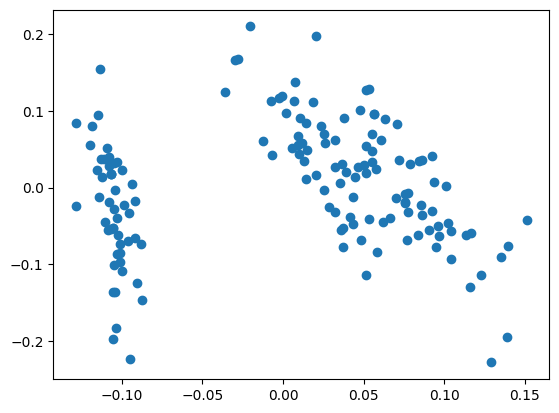

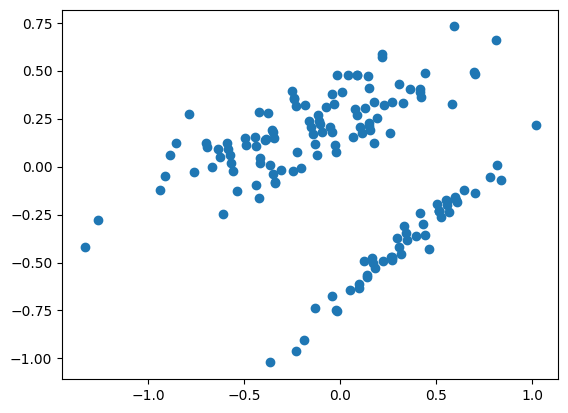

In [56]:
import matplotlib.pyplot as plt

plt.scatter(U[:,0], U[:,1])
plt.show()

plt.scatter(U_pred[:,0],U_pred[:,1])
plt.show()

#2 A simple MLP

In [57]:
import pandas as pd

df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None)
df = df.sample(frac=1) #shuffle

# add label indices column
mapping = {k: v for v, k in enumerate(df[4].unique())}
df[5] = df[4].map(mapping)

# normalise data
alldata = torch.tensor(df.iloc[:, [0,1,2,3]].values, dtype=torch.float)
alldata = (alldata - alldata.mean(dim=0)) / alldata.var(dim=0)

# create datasets
targets_tr = torch.tensor(df.iloc[:100, 5].values, dtype=torch.long)
targets_va = torch.tensor(df.iloc[100:, 5].values, dtype=torch.long)

data_tr = alldata[:100]
data_va = alldata[100:]

In [82]:
# toy MLP
w1 = torch.randn((4, 12), requires_grad=True)
w2 = torch.randn((12, 3), requires_grad=True)
b1 = torch.tensor(0.0, requires_grad=True)
b2 = torch.tensor(0.0, requires_grad=True)

num_epochs = 100
lr = 0.01 # learning rate

for epoch in range(num_epochs):
  w1.grad = None
  w2.grad = None
  b1.grad = None
  b2.grad = None

  logits = torch.relu(data_tr @ w1 + b1) @ w2 + b2
  loss = torch.nn.functional.cross_entropy(logits, targets_tr)

  loss.backward()

  w1.data = w1 - w1.grad * lr
  w2.data = w2 - w2.grad * lr
  b1.data = b1 - b1.grad * lr
  b2.data = b2 - b2.grad * lr


# model parameters
w1, w2, b1, b2  = w1.data, w2.data, b1.data, b2.data

def accuracy(pred, truth):
  clazz = torch.argmax(pred, dim=1)
  correct = (clazz == truth).sum().item()
  return correct / pred.size(0)

pred = torch.relu(data_tr @ w1 + b1) @ w2 + b2
acc = accuracy(pred, targets_tr)
print(f"Training accuracy: {acc}")

pred = torch.relu(data_va @ w1 + b1) @ w2 + b2
acc = accuracy(pred, targets_va)
print(f"Validation accuracy: {acc}")

Training accuracy: 0.83
Validation accuracy: 0.84
